# 05 Memory vs Rechallenge

Compare gene expression between IEL memory CD8 T cells and rechallenged CD8 T cells, following the structure of the tutorial's Notebook 06.

In [ ]:
import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

import scanpy as sc
import pandas as pd
import numpy as np
from scipy import sparse

from src.paths import INTERMEDIATE_DIR, RESULTS_DIR

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")


## Load Annotated CD8 Data

Use the annotated object from notebook 04. The comparison uses `sample_group`: `sIEL` is IEL memory and `rechallenge` is the rechallenge condition.

In [32]:
input_file = INTERMEDIATE_DIR / "04_cell_annotation.h5ad"
adata = sc.read_h5ad(input_file)

adata


AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5', 'cell_type_manual', 'cd8_subset'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_manual_colors', 'hash_id_colors', 'hvg', 'leiden_0_5', 'leiden_0_5_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups

In [33]:
adata.obs["sample_group"].value_counts()


sample_group
sIEL           5023
sLPL           4249
rechallenge    3934
Name: count, dtype: int64

## Keep IEL Memory and Rechallenge

Exclude `sLPL` for this specific comparison.

In [34]:
comparison_groups = ["sIEL", "rechallenge"]
comparison = adata[adata.obs["sample_group"].isin(comparison_groups)].copy()

comparison.obs["condition"] = comparison.obs["sample_group"].map(
    {
        "sIEL": "IEL_memory",
        "rechallenge": "rechallenge",
    }
)

comparison.obs["condition"] = pd.Categorical(
    comparison.obs["condition"],
    categories=["IEL_memory", "rechallenge"],
    ordered=True,
)

comparison.obs["condition"].value_counts()


condition
IEL_memory     5023
rechallenge    3934
Name: count, dtype: int64

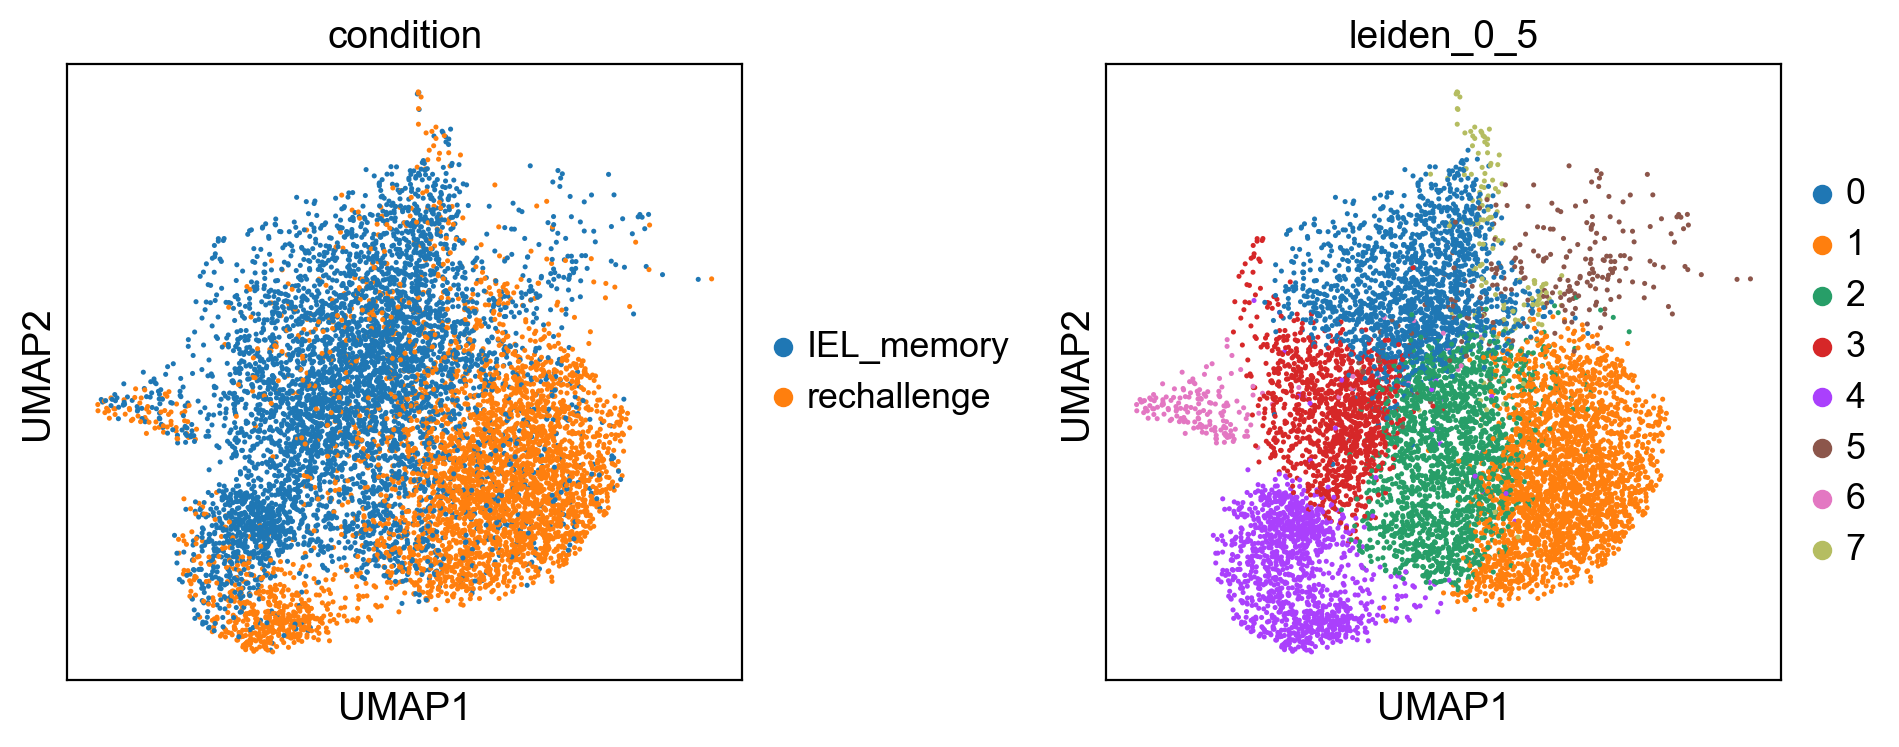

In [35]:
sc.pl.umap(
    comparison,
    color=["condition", "leiden_0_5"],
    wspace=0.4,
)


## Differential Expression

Build a log-normalized expression object from the preserved raw count layer before ranking genes. Notebook 02 keeps raw counts in `layers["counts"]` and stores full-gene log-normalized expression in `.raw`, so DE uses the count layer and `use_raw=False`.


In [ ]:
de_adata = comparison.copy()

if "counts" in de_adata.layers:
    de_adata.X = de_adata.layers["counts"].copy()
elif "raw_counts" in de_adata.layers:
    de_adata.X = de_adata.layers["raw_counts"].copy()
elif comparison.raw is not None:
    print("WARNING: no count layer found; falling back to comparison.raw")
    de_adata = comparison.raw.to_adata().copy()
    de_adata.obs = comparison.obs.copy()
    de_adata.obsm["X_umap"] = comparison.obsm["X_umap"].copy()
else:
    raise ValueError("No count layer or raw object is available for DE")

de_adata.uns.pop("log1p", None)
sc.pp.normalize_total(de_adata, target_sum=1e4)
sc.pp.log1p(de_adata)

sc.tl.rank_genes_groups(
    de_adata,
    groupby="condition",
    groups=["rechallenge"],
    reference="IEL_memory",
    method="wilcoxon",
    use_raw=False,
)


In [ ]:
de_df = sc.get.rank_genes_groups_df(de_adata, group="rechallenge")
de_df = de_df.rename(columns={"scores": "wilcoxon_z_score"})

de_file = RESULTS_DIR / "05_DE_rechallenge_vs_IEL_memory_all_CD8.xlsx"
de_file.parent.mkdir(parents=True, exist_ok=True)
de_df.to_excel(de_file, index=False)

print("Saved:", de_file)
de_df.head(20)


In [ ]:
sc.pl.rank_genes_groups(de_adata, n_genes=25, sharey=False)


## DEG Z Scores

`wilcoxon_z_score` is the signed Scanpy Wilcoxon test statistic. The table below also z-scores each selected gene across cells, then averages those expression z-scores within `IEL_memory` and `rechallenge`.


In [ ]:
top_n_per_direction = 25

significant_de = de_df.loc[de_df["pvals_adj"].lt(0.05)].copy()
if significant_de.empty:
    significant_de = de_df.copy()

rechallenge_up = (
    significant_de
    .sort_values("wilcoxon_z_score", ascending=False)
    .head(top_n_per_direction)
    .assign(direction="rechallenge_up")
)
iel_memory_up = (
    significant_de
    .sort_values("wilcoxon_z_score", ascending=True)
    .head(top_n_per_direction)
    .assign(direction="IEL_memory_up")
)

top_de_table = (
    pd.concat([rechallenge_up, iel_memory_up], ignore_index=True)
    .drop_duplicates("names")
)
top_de_genes = top_de_table["names"].tolist()

print(f"Selected {len(top_de_genes)} genes for z-score summary")
top_de_table[["names", "direction", "wilcoxon_z_score", "logfoldchanges", "pvals_adj"]]


In [ ]:
def expression_frame(adata, genes):
    matrix = adata[:, genes].X
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return pd.DataFrame(matrix, index=adata.obs_names, columns=genes)

expr = expression_frame(de_adata, top_de_genes)
gene_std = expr.std(axis=0, ddof=0).replace(0, np.nan)
z_expr = expr.sub(expr.mean(axis=0), axis=1).div(gene_std, axis=1).fillna(0)
z_expr["condition"] = de_adata.obs["condition"].to_numpy()

condition_mean_z = (
    z_expr
    .groupby("condition", observed=True)
    .mean()
    .T
    .loc[top_de_genes, ["IEL_memory", "rechallenge"]]
)
condition_mean_z["delta_rechallenge_minus_IEL_memory"] = (
    condition_mean_z["rechallenge"] - condition_mean_z["IEL_memory"]
)
condition_mean_z = condition_mean_z.join(
    top_de_table.set_index("names")[[
        "direction", "wilcoxon_z_score", "logfoldchanges", "pvals_adj"
    ]]
)

zscore_file = RESULTS_DIR / "05_DE_rechallenge_vs_IEL_memory_top50_expression_zscores.csv"
condition_mean_z.to_csv(zscore_file)
print("Saved:", zscore_file)
condition_mean_z


In [ ]:
plot_adata = de_adata[:, top_de_genes].copy()
plot_expr = expression_frame(plot_adata, top_de_genes)
plot_std = plot_expr.std(axis=0, ddof=0).replace(0, np.nan)
plot_adata.X = plot_expr.sub(plot_expr.mean(axis=0), axis=1).div(plot_std, axis=1).fillna(0).to_numpy()

sc.pl.matrixplot(
    plot_adata,
    var_names=top_de_genes,
    groupby="condition",
    use_raw=False,
    cmap="vlag",
    vmin=-1,
    vmax=1,
    swap_axes=True,
)


## Inspect CD8 Memory and Rechallenge Genes

Plot a focused gene panel across the two conditions.

Present: ['Cd3e']
Missing: []


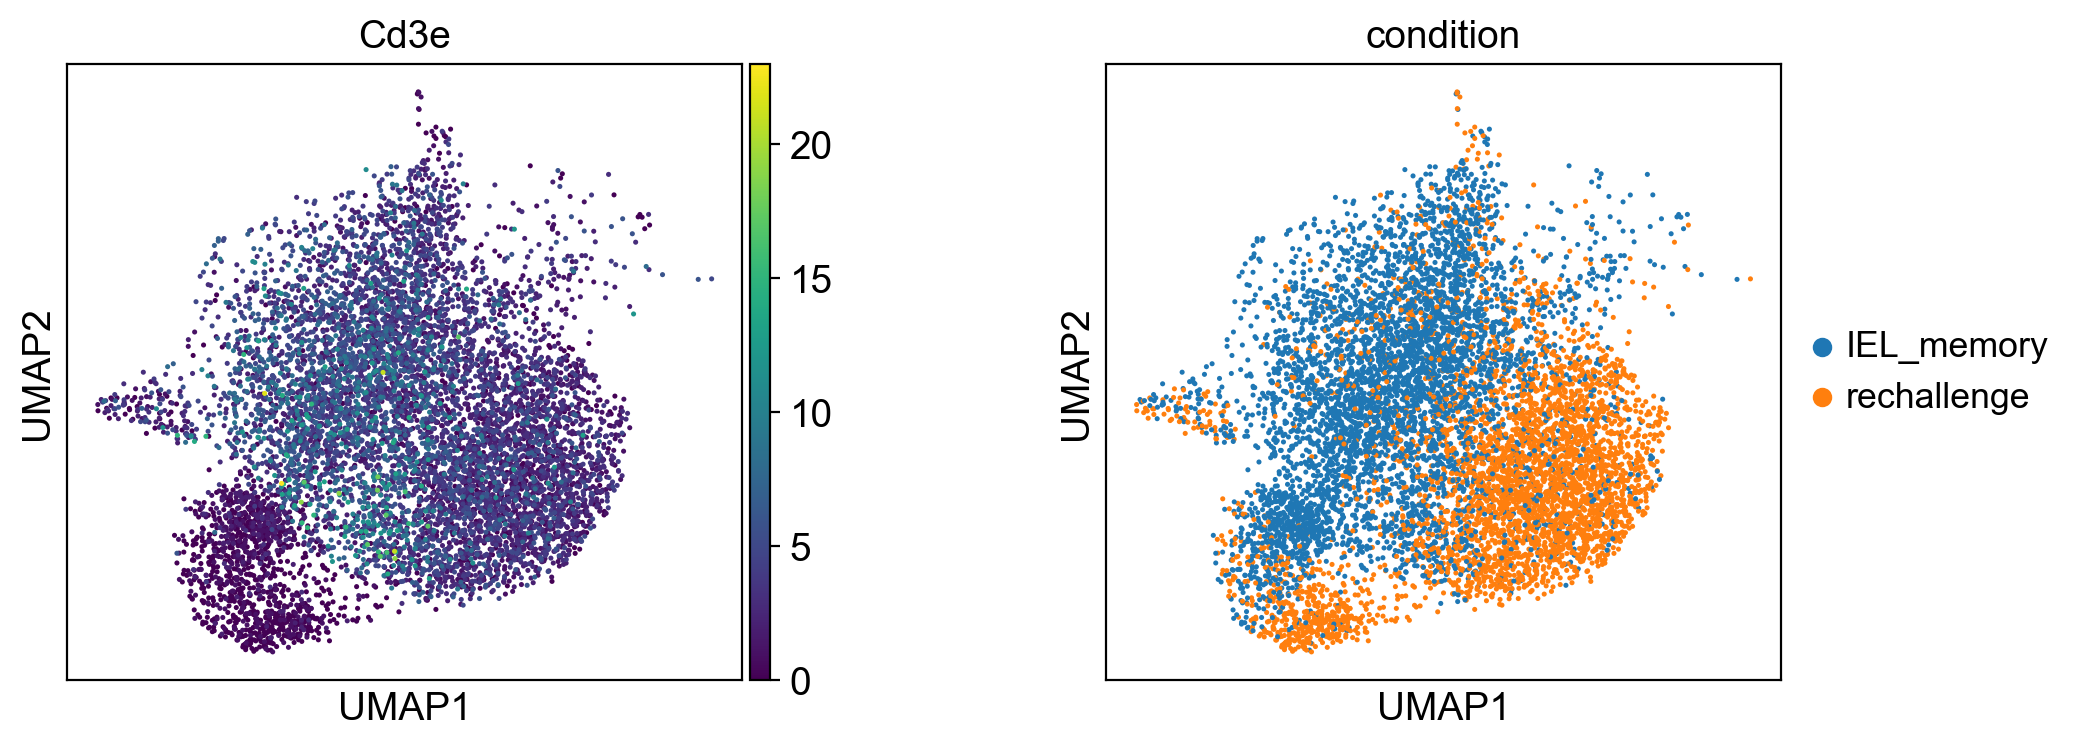

In [46]:
genes_to_plot = [
    "Cd3e"
]

var_names = comparison.raw.var_names if comparison.raw is not None else comparison.var_names
genes_present = [gene for gene in genes_to_plot if gene in var_names]
genes_missing = [gene for gene in genes_to_plot if gene not in var_names]

print("Present:", genes_present)
print("Missing:", genes_missing)

sc.pl.umap(
    comparison,
    color=genes_present + ["condition"],
    use_raw=True,
    wspace=0.4,
)

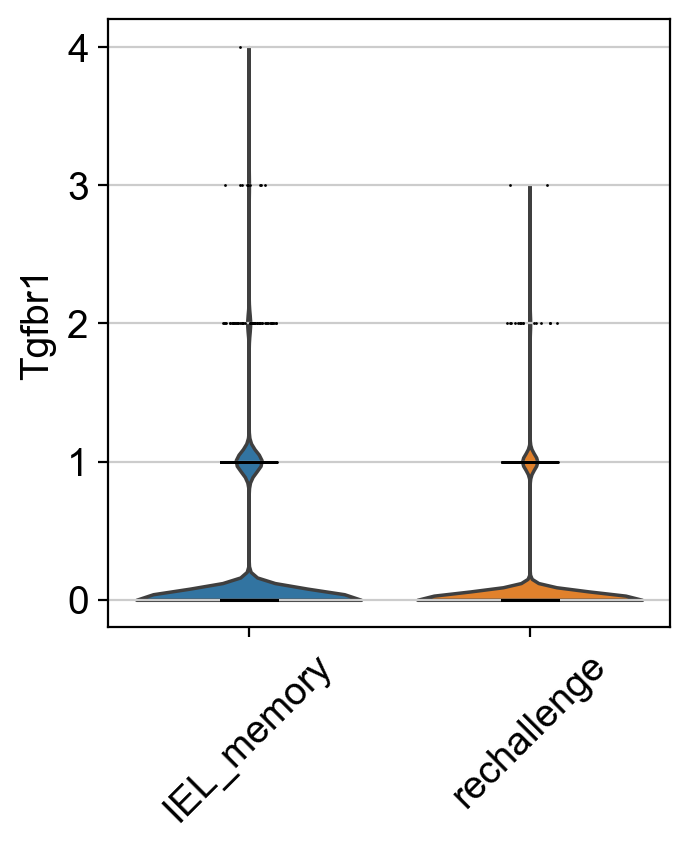

In [39]:
sc.pl.violin(
    comparison,
    keys=genes_present,
    groupby="condition",
    use_raw=True,
    rotation=45,
)


## Optional: Cluster-Aware Comparison

The table below shows how many cells from each condition are in each cluster. Use this before interpreting DE results, because condition imbalance across clusters can drive gene differences.

In [40]:
condition_cluster_counts = pd.crosstab(
    comparison.obs["leiden_0_5"],
    comparison.obs["condition"],
)

condition_cluster_counts


condition,IEL_memory,rechallenge
leiden_0_5,,
0,1421,206
1,306,2226
2,1143,732
3,1069,77
4,698,525
5,189,47
6,114,65
7,83,56


In [ ]:
counts_file = RESULTS_DIR / "05_condition_cluster_counts.csv"
condition_cluster_counts.to_csv(counts_file)
print("Saved:", counts_file)

comparison_file = INTERMEDIATE_DIR / "05_memory_vs_rechallenge.h5ad"
de_adata.write_h5ad(comparison_file)
print("Saved:", comparison_file)


Note: this cell-level Wilcoxon result is useful for exploration. For a condition-level statistical test, use pseudobulk by biological replicate or sample when replicate metadata are available.